# Data loadings and preparations

> Fill in a module description here


In [ ]:
#| default_exp data.__init__

In [ ]:
#| hide
from nbdev.showdoc import *

In [ ]:
#| export
import importlib
from dataclasses import dataclass
from typing import Dict
from omegaconf import OmegaConf, DictConfig
from dataclasses import is_dataclass, asdict

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.distributed as dist

from fastcore.utils import *
from flwr_datasets import FederatedDataset
from flwr_datasets.partitioner import *

from fedai.data.vision import VisionBlock
from fedai.core import get_clean_kwargs

In [ ]:
#| export
def init_data(cfg):
    if cfg.name != "mnist_rotated_batched":
        module = importlib.import_module("flwr_datasets.partitioner")
    else: 
        module = importlib.import_module("fedai.data.vision.partitioners")
    
    partitioner_cls = getattr(module, cfg.partitioner.cls)
        
    kwargs = get_clean_kwargs(cfg.partitioner)
    kwargs.pop("cls", None)
    
    partitioner = partitioner_cls(**kwargs)
    test_partitioner = partitioner_cls(**kwargs)
    
    fds = FederatedDataset(dataset= cfg.hf_name, partitioners= {"train": partitioner, "test": test_partitioner})
    
    return fds

In [ ]:
#| hide
from fedai.cfgs.data import MNISTRotatedPatchedConfig
cfg = MNISTRotatedPatchedConfig()
fds = init_data(cfg)


In [ ]:
#| export
def get_block(cfg, client_id, fds= None, train=True):

    if cfg.modality.lower() == "vision":
        return VisionBlock(cfg, client_id, train= train, fds= fds)

In [ ]:
#| hide
block = get_block(cfg, client_id= 19, fds= fds, train=True)

Partition 19: Cluster 4, Rot: 270°, Noise: 50.0%


torch.Size([1, 28, 28]) tensor(-0.4242) tensor(2.8215)
1


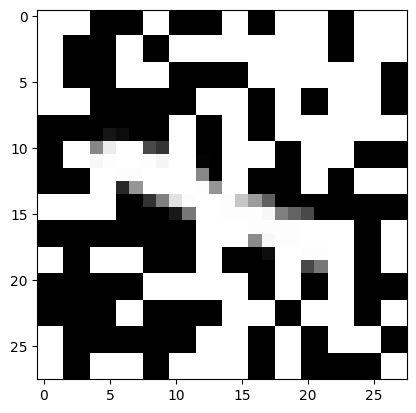

In [ ]:
#| hide
image, label = block[2]["image"], block[2]["label"]
print(image.shape, image.min(), image.max())
# denomralize = lambda x: x * torch.tensor(IMG_DATA_CONFIGS[cfg.data.name].std).view(-1, 1, 1) + torch.tensor(IMG_DATA_CONFIGS[cfg.data.name].mean).view(-1, 1, 1)
# image = denomralize(image)
plt.imshow(image.permute(1, 2, 0), cmap= "gray" if image.shape[0] == 1 else None)
print(label)
plt.show()

In [ ]:
#| export
def prepare_dl_dist(
        cfg,
        client_id,
        fds,
        train= True,
        collator=torch.utils.data.default_collate,
):
    block = get_block(cfg= cfg, client_id= client_id, fds= fds, train= train)

    dist_sampler = torch.utils.data.distributed.DistributedSampler(block)

    data_loader = torch.utils.data.DataLoader(
        block,
        collate_fn=collator,
        sampler=dist_sampler,
        batch_size=cfg.batch_size, 
        drop_last=cfg.loader.drop_last,
        pin_memory=cfg.loader.pin_memory,
        num_workers=cfg.loader.num_workers,
        persistent_workers=(cfg.loader.num_workers > 0) and cfg.loader.persistent_workers,
    )


    return data_loader, dist_sampler

In [ ]:
#| export
def prepare_dl(cfg, client_id, fds, train=True, distributed=False):
    if distributed and torch.distributed.is_initialized():
        return prepare_dl_dist(cfg, client_id, fds, train)
    
    block = get_block(cfg, client_id, fds, train)
    dl = torch.utils.data.DataLoader(block, batch_size= cfg.batch_size, shuffle= True if train else False) # TODO: make sure you put batch_size to dataConfig keys
    return dl

In [ ]:
#| hide
cfg.batch_size = 128
dl = prepare_dl(cfg, client_id=15, fds= fds, train=True)
batch = next(iter(dl))
print(batch["image"].shape, batch["label"].shape)

Partition 15: Cluster 4, Rot: 270°, Noise: 50.0%
torch.Size([128, 1, 28, 28]) torch.Size([128])


In [ ]:
type(cfg)

fedai.cfgs.data.MNISTRotatedPatchedConfig

In [ ]:
#| hide
dist.init_process_group(backend="gloo", init_method="tcp://localhost:12345", rank=0, world_size=1)
cfg.loader = OmegaConf.create({})
cfg.loader.pin_memory= False
cfg.loader.drop_last= False
cfg.loader.num_workers= 0
cfg.loader.persistent_workers= False
dist_dl, dist_sampler = prepare_dl(cfg, client_id=15, fds= fds, train=True, distributed=True)
dist.destroy_process_group()


[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
Partition 15: Cluster 4, Rot: 270°, Noise: 50.0%


In [ ]:
#| hide
dist_sampler.set_epoch(0)
batch= next(iter(dist_dl))
print(batch["image"].shape, batch["label"].shape)

torch.Size([128, 1, 28, 28]) torch.Size([128])


In [ ]:
#| hide
import nbdev
nbdev.nbdev_export()